In [40]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import numpy as np
import pandas as pd
import pegasus as pg
import json
import os
import pegasusio
from pegasusio import UnimodalData, MultimodalData
import matplotlib.pyplot as plt 
import scipy.sparse
import matplotlib.patches as mpatches
import itertools
from matplotlib import cm
import scanpy as sc
from matplotlib.pyplot import rc_context
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import mannwhitneyu
from utils.lists import *
from utils.plot_utils import *
from matplotlib_venn import venn2, venn2_circles

# Fig. 1b RNA UMAP and Cell Proportions

In [2]:
data = pg.read_input('/gpfs/gibbs/pi/gerstein/jz435/ShareZhangLab/PTSD/RNA/data/RNA_FINAL.zarr')
data

2023-11-01 14:21:28,334 - pegasusio.readwrite - INFO - zarr file '/gpfs/gibbs/pi/gerstein/jz435/ShareZhangLab/PTSD/RNA/data/RNA_FINAL.zarr' is loaded.
2023-11-01 14:21:28,336 - pegasusio.readwrite - INFO - Function 'read_input' finished in 340.50s.


MultimodalData object with 1 UnimodalData: 'GRCh38-rna'
    It currently binds to UnimodalData object GRCh38-rna

UnimodalData object with n_obs x n_vars = 935371 x 27982
    Genome: GRCh38; Modality: rna
    It contains 2 matrices: 'X', 'raw.X'
    It currently binds to matrix 'X' as X

    obs: 'n_genes', 'n_counts', 'percent_mito', 'doublet', 'doublet_score', 'Channel', 'scale', 'leiden_labels'(cluster), 'hodge_anno', 'lake_anno', 'nenad_anno', 'fine_anno', 'subclass', 'class', 'BrNum', 'Condition', 'Sex', 'Smoking', 'Antidepressant', 'PMI', 'RIN', 'Race', 'AgeDeath', 'subclass2', 'subclass_renamed', 'subclass_final'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'(basis), 'pca_harmony_knn_distances'(knn), 'pca_harmony_knn_indices'(knn)
    varm: 'means', 'partial_sum', 'de_res'
    obsp: 'W_pca_harmony'
    uns: 'genome', 'leiden_resolution', 'modality', 'norm_

In [12]:
ann = sc.AnnData(data.X)
ann.var_names = data.var_names
ann.obs_names = data.obs_names

In [13]:
ann.obs['Subclass'] = data.obs['subclass_renamed']
ann.obsm['umap'] = data.obsm['X_umap']

In [17]:
colors = [subclass_colors[x] for x in ann.obs.Subclass.cat.categories]

/gpfs/gibbs/project/gerstein/ah2428/conda_envs/RNA/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/gpfs/gibbs/project/gerstein/ah2428/conda_envs/RNA/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


/gpfs/gibbs/project/gerstein/ah2428/conda_envs/RNA/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


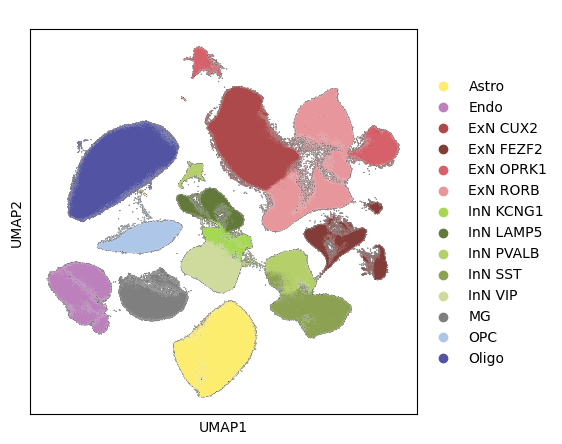

In [20]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

with rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(ann, color='Subclass', size=1, add_outline=True,palette=colors,save='_rna_no_labels.pdf',title=' ')

In [118]:
meta = pd.read_csv('/gpfs/gibbs/pi/gerstein/jz435/ShareZhangLab/PTSD/RNA/data/RNA_FINAL_meta.csv',sep='\t')

In [143]:
arr = np.zeros((3,14))
for ii,cond in enumerate(['CON','MDD','PTSD']):
    x = meta[meta.Condition==cond].subclass_renamed.value_counts()/meta[meta.Condition==cond].subclass_renamed.value_counts().sum()
    x = x.reindex(['CUX2','RORB','FEZF2','OPRK1','LAMP5','KCNG1','VIP','SST','PVALB','ODC','OPC','END','ASC','MG'])
    print(x.values)
    arr[ii] = x.values

[0.15686969 0.13306651 0.03720404 0.03664527 0.02320867 0.01382319
 0.03738272 0.04513411 0.03545625 0.20486589 0.05664423 0.03168451
 0.14294254 0.04507238]
[0.16041701 0.13224471 0.03805245 0.03851558 0.02366385 0.01397273
 0.0385975  0.04648335 0.04070522 0.214468   0.05209764 0.03910159
 0.12082393 0.04085645]
[0.1872604  0.12740246 0.03382546 0.03402536 0.02454288 0.01545699
 0.04160232 0.04532308 0.03928409 0.16085391 0.05749458 0.04179899
 0.15123924 0.03989025]


In [145]:
df = pd.DataFrame(arr)
df.index = ['CON','MDD','PTSD']
df.columns = ['CUX2','RORB','FEZF2','OPRK1','LAMP5','KCNG1','VIP','SST','PVALB','ODC','OPC','END','ASC','MG']
df = df.reindex(['PTSD','MDD','CON'])

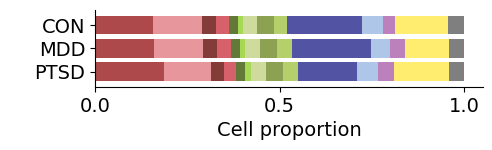

In [151]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots()
df.plot(stacked=True,kind='barh',color=[subclass_colors[c] for c in df.columns],figsize=(5,1),width=0.8,legend=None, ax=ax)
ax.set_xlabel('Cell proportion')
ax.set_xticks([0,0.5,1])
ax.set_ylabel(' ')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.savefig('/home/ah2428/figs/rna_proportions.pdf',bbox_inches='tight')

# Fig. 1c ATAC UMAP and Cell Proportions

In [4]:
atac = pd.read_csv('/gpfs/gibbs/pi/gerstein/jz435/ShareZhangLab/PTSD/ATAC/data/atac_umap.txt',sep='\t')
atac_meta = pd.read_csv('/gpfs/gibbs/pi/gerstein/jz435/ShareZhangLab/PTSD/ATAC/data/ATAC_FINAL_meta.csv',sep='\t')
atac['Celltype'] = atac_meta['Int_Cluster'].values

In [5]:
atac['Celltype'] = atac['Celltype'].astype('category')

In [6]:
ann = sc.AnnData(np.empty((473033,2)))

In [7]:
ann.obs_names = atac.index

In [8]:
ann.obs['Celltype'] = atac['Celltype']

In [9]:
ann.obsm['umap'] = np.array(atac[['umap1','umap2']])

In [11]:
colors = [class_colors2[x] for x in ann.obs.Celltype.cat.categories]

/gpfs/gibbs/project/gerstein/ah2428/conda_envs/RNA/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/gpfs/gibbs/project/gerstein/ah2428/conda_envs/RNA/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


/gpfs/gibbs/project/gerstein/ah2428/conda_envs/RNA/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


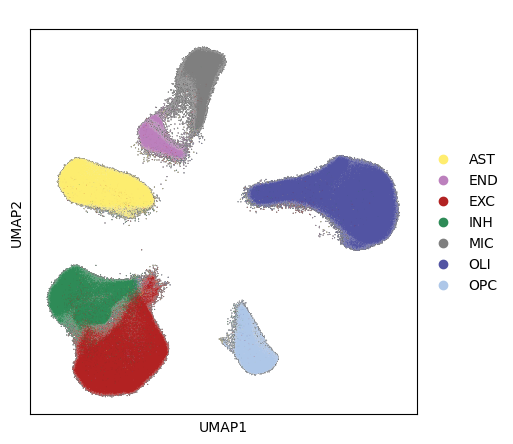

In [12]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

with rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(ann, color='Celltype', size=1, add_outline=True,palette=colors,save='_atac_no_labels.pdf',title=' ')

In [107]:
meta = atac_meta
arr = np.zeros((3,7))
for ii,cond in enumerate(['CON','MDD','PTSD']):
    print(cond)
    x = meta[meta.Condition==cond]['Int_Cluster'].value_counts()/meta[meta.Condition==cond]['Int_Cluster'].value_counts().sum()
    x = x.reindex(['EXC','INH','OLI','OPC','END','AST','MIC'])
    arr[ii] = x.values

CON
MDD
PTSD


In [108]:
df = pd.DataFrame(arr)
df.index = ['CON','MDD','PTSD']
df.columns = ['EXN','INH','ODC','OPC','END','ASC','MG']
df = df.reindex(['PTSD','MDD','CON'])

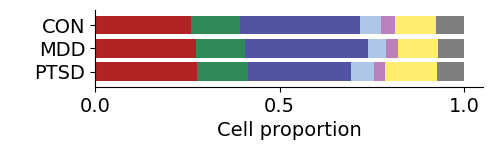

In [114]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
fig, ax = plt.subplots()

colors = [class_colors[x] for x in df.columns]
df.plot(stacked=True,kind='barh',color=colors,figsize=(5,1),width=0.8,legend=None, ax=ax)
ax.set_xlabel('Cell proportion')
ax.set_xticks([0,0.5,1])
ax.set_ylabel(' ')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

    
plt.savefig('/home/ah2428/figs/atac_proportions.pdf',bbox_inches='tight',dpi=300)

# Fig. 1d Multiome UMAP and Cell Proportions

In [81]:
meta = pd.read_csv('/gpfs/gibbs/pi/gerstein/jz435/ShareZhangLab/PTSD/Multiome/data/MULTIOME_FINAL_meta.csv',sep='\t')

In [82]:
umap = pd.read_csv('/gpfs/gibbs/pi/gerstein/jz435/ShareZhangLab/PTSD/Multiome/data/multiome_umap.csv',sep=',',index_col=0)

In [83]:
ann = sc.AnnData(np.empty((umap.shape[0],2)))
ann.obs_names = umap.index
ann.obsm['umap'] = np.array(umap[['umap1','umap2']])

In [84]:
ann.obs['subclass'] = meta['subclass'].values
ann.obs['subclass'] = ann.obs['subclass'].astype('category')

In [87]:
colors = [subclass_colors[x] for x in ann.obs.subclass.cat.categories]

/gpfs/gibbs/project/gerstein/ah2428/conda_envs/RNA/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:369: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/gpfs/gibbs/project/gerstein/ah2428/conda_envs/RNA/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:379: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/gpfs/gibbs/project/gerstein/ah2428/conda_envs/RNA/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


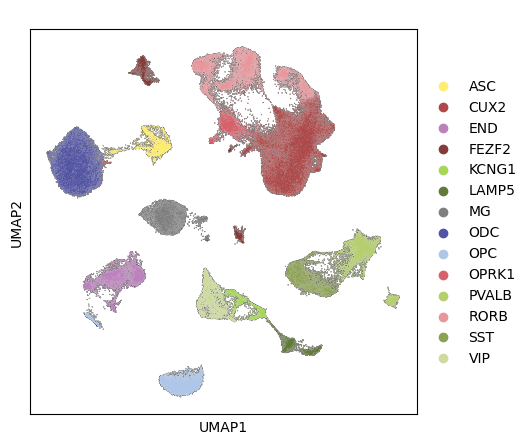

In [76]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
with rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(ann, color='subclass', size=1, add_outline=True, palette=colors,save='_multiome_no_labels.pdf',title=' ')

In [171]:
#meta = data.obs
arr = np.zeros((3,14))
for ii,cond in enumerate(['CON','MDD','PTSD']):
    print(cond)
    x = meta[meta.Condition==cond].subclass.value_counts()/meta[meta.Condition==cond].subclass.value_counts().sum()
    x = x.reindex(['ExN CUX2','ExN RORB','ExN FEZF2','ExN OPRK1','InN LAMP5','InN KCNG1','InN VIP','InN SST','InN PVALB','Oligo','OPC','Endo','Astro','MG'])
    print(x.values)
    arr[ii] = x.values

CON
[0.22020295 0.11346863 0.03376384 0.03530904 0.02022601 0.01845018
 0.04112085 0.04734779 0.05765683 0.18023524 0.074631   0.05961716
 0.02859779 0.06937269]
MDD
[0.30221519 0.13117842 0.01808318 0.0255425  0.02373418 0.01717902
 0.05801688 0.06781193 0.06871609 0.10232068 0.06133213 0.045434
 0.0287824  0.04965341]
PTSD
[0.28431981 0.0995398  0.02614691 0.03466616 0.02275514 0.01995255
 0.04557397 0.04555805 0.06312202 0.12969952 0.06248507 0.07011258
 0.03605153 0.06001688]


In [172]:
df = pd.DataFrame(arr)
df.index = ['CON','MDD','PTSD']
df.columns = ['CUX2','RORB','FEZF2','OPRK1','LAMP5','KCNG1','VIP','SST','PVALB','ODC','OPC','END','ASC','MG']

In [173]:
df = df.reindex(['PTSD','MDD','CON'])

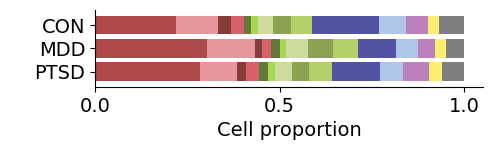

In [175]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots()
df.plot(stacked=True,kind='barh',color=[subclass_colors[x] for x in df.columns],figsize=(5,1),width=0.8,legend=None, ax=ax)
ax.set_xlabel('Cell proportion')
ax.set_xticks([0,0.5,1])
ax.set_ylabel(' ')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.savefig('/home/ah2428/figs/multiome_proportions.pdf',bbox_inches='tight',dpi=300)

# Fig. 1e DEG counts

In [3]:
deg = pd.read_csv('/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/snRNA/PTSD_vs_CON/MAST_WILCOX_intersect.csv',sep='\t')

In [7]:
ups, downs = [], []
for celltype in ['EXC','INH','OLI','OPC','END','AST','MIC','CUX2','RORB','FEZF2','OPRK1','LAMP5','KCNG1','VIP','SST','PVALB']:
    deg_celltype = deg[deg.Celltype==celltype]
    deg_up = deg_celltype[deg_celltype.log2FC > 0]
    deg_down = deg_celltype[deg_celltype.log2FC < 0]
    ups.append(deg_up.shape[0])
    downs.append(deg_down.shape[0])

/gpfs/gibbs/pi/gerstein/jz435/ShareZhangLab/ah2428/PTSDsnDLPFC/utils/plot_utils.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  f.tight_layout()


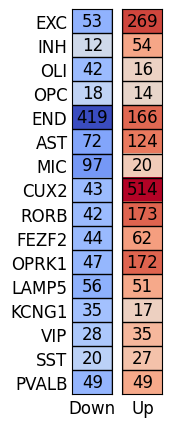

In [8]:
deg_counts_plot(ups,downs,['EXC','INH','OLI','OPC','END','AST','MIC','CUX2','RORB','FEZF2','OPRK1','LAMP5','KCNG1','VIP','SST','PVALB'])

# Fig. 1f PTSD snDEGs binary plot

In [12]:
deg_all = pd.read_csv('/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/snRNA/PTSD_vs_CON/MAST_WILCOX_intersect.csv',sep='\t')
deg_all = deg[deg.Celltype.isin(['EXC','INH','OLI','OPC','END','AST','MIC'])]

N=len(deg_all.Genename.unique())
N

1184

In [10]:
deg

,Unnamed: 0,Genename,Celltype,log2FC,FDR
0,0,ACTG1,CUX2,0.631635,0.000000e+00
1,1,AP1S1,CUX2,0.517209,0.000000e+00
2,2,ARF1,CUX2,0.455992,0.000000e+00
3,3,ATP1A1,CUX2,0.373658,0.000000e+00
4,4,ATP6AP1,CUX2,0.667018,0.000000e+00
...,...,...,...,...,...
2835,2835,PDE3A,INH,-0.333088,3.029254e-72
2836,2836,GPR149,INH,-0.276180,5.500102e-59
2837,2837,UTRN,INH,-0.372871,1.581509e-58
2838,2838,ZNF804B,INH,-0.297199,3.038661e-50


In [14]:
degs = []
for celltype in ['EXC','INH','OLI','OPC','END','AST','MIC']:
    deg = deg_all[deg_all.Celltype==celltype]
    deg_up = deg[deg['log2FC'] > 0].Genename
    deg_down = deg[deg['log2FC'] < 0].Genename
    deg_up_down = list(itertools.chain(*[deg_up,deg_down]))
    print(len(deg_up_down))
    degs.append(deg_up_down)

322
66
58
32
585
196
117


In [15]:
# shared DEG across EXN and IN
len(list(set(degs[0]) & set(degs[1]))) / len(list(set(list(degs[0]+degs[1]))))

0.09915014164305949

In [16]:
# shared DEG across all celltypes
len(list(set.intersection(*map(set, degs))))

0

In [17]:
all_degs = list(set(list(itertools.chain(*degs))))
len(all_degs)

1184

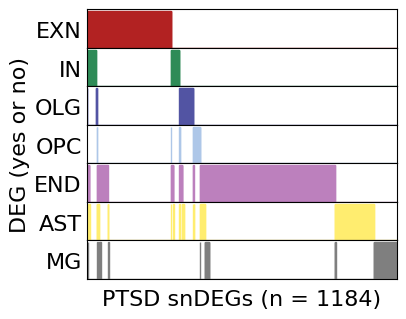

In [18]:
all_vals = []
for i in range(7):
    vals = []
    for deg in all_degs:
        if deg in degs[i]:
            val = 1
        else:
            val = 0
        vals.append(val)
    all_vals.append(vals)
arr = np.array(all_vals)
celltypes = ['EXN','IN','OLG','OPC','END','AST','MG']
df = pd.DataFrame(arr.T,columns=celltypes,index=all_degs)
df1 = df.sort_values(by=celltypes,ascending=False)

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = '16'

colors = list(celltype_colors2.values())
fig, ax = plt.subplots(7,1,sharex=True,figsize=(4,3.5),frameon=True)
ax = ax.flatten()

for ii,s in enumerate(celltypes):
    df1[[s]].plot.bar(ax=ax[ii],width=1,color=colors[ii],edgecolor=colors[ii])
    ax[ii].get_legend().remove()
    ax[ii].set_xticks([])
    ax[ii].set(yticks=np.array([0.5]),yticklabels=[s])
    ax[ii].tick_params(axis=u'both', which=u'both',length=0)
ax[3].set_ylabel('DEG (yes or no)',rotation=90)
n_deg = df1.shape[0]

plt.xlabel(f'PTSD snDEGs (n = {n_deg})')
fig.subplots_adjust(wspace=0,hspace=0)

# Fig. 1g PTSD DEG heatmap

In [19]:
deg = pd.read_csv('/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/snRNA/PTSD_vs_CON/MAST_WILCOX_intersect.csv',sep='\t')

In [20]:
deg['abs'] = np.abs(deg.log2FC)

In [24]:
num=8
top_genes = []
for celltype in ['EXC','INH','OLI','OPC','END','AST','MIC']:
    top = deg[deg.Celltype==celltype].sort_values(by=['FDR','abs'],ascending=[True,False])
    top = top[:num]
    top = top.sort_values('log2FC')
    top_genes.append(top.Genename.values)
    print(celltype,top.Genename.values)

EXC ['ETV5' 'BACH2' 'PCDH11X' 'SLC8A3' 'UST' 'NACA' 'FAU' 'JUN']
INH ['SPRED2' 'ANKRD55' 'BACH2' 'PDE10A' 'ETV5' 'PCSK1N' 'CALM1' 'JUN']
OLI ['CTNNA2' 'ARPP21' 'CSMD3' 'NAV3' 'PDE1A' 'MDGA2' 'CADM2' 'FKBP5']
OPC ['CADPS2' 'RALYL' 'GPNMB' 'GPC5' 'CD81' 'PLPP4' 'FKBP5' 'RASD1']
END ['GPCPD1' 'HSPA1A' 'EEF1A1' 'TPT1' 'EIF1' 'CD59' 'YBX3' 'CEBPD']
AST ['RASD1' 'ARHGEF3' 'SLC39A14' 'OSMR' 'GADD45B' 'YBX3' 'ZFP36' 'SERPINA3']
MIC ['HDAC9' 'ACTB' 'ARHGAP15' 'RAPGEF1' 'TMEM163' 'CEBPD' 'PLTP' 'SLC11A1']


In [25]:
ordered_genes = []

for x in top_genes[0]:
    ordered_genes.append(x)
    
for i in top_genes[1:]:
    for j in i:
        if j in ordered_genes:
            pass
        else:
            ordered_genes.append(j)

len(ordered_genes)

49

In [29]:
fcs_all = []
for ii,gene in enumerate(ordered_genes):
    df = deg[deg.Genename==gene]
    fcs = []
    for celltype in ['EXC','INH','OLI','OPC','END','AST','MIC']:
        if celltype in df.Celltype.values:
            celltype_fc = df[df.Celltype==celltype].log2FC.values[0]
        else:
            celltype_fc = 0.0
        fcs.append(celltype_fc)
    fcs_all.append(fcs)
    
fcs_all = np.array(fcs_all)
bulk_deg = pd.read_csv('/gpfs/gibbs/pi/gerstein/jz435/ShareZhangLab/PTSD/RNA/jiawei_ptsd_degs.csv')

bulk_df = bulk_deg[bulk_deg.Genename.isin(ordered_genes)]
bulk_vals = bulk_df.set_index('Genename').reindex(ordered_genes)['PTSD.dlPFC.log2FoldChange'].values
bulk_vals = bulk_vals.reshape(len(ordered_genes),1)
df = pd.DataFrame(fcs_all,index=ordered_genes)
df2 = df.reindex(ordered_genes)
bulk_df[bulk_df['PTSD.dlPFC.padj']<0.01]

,Geneid,Genename,PTSD.OFC.log2FoldChange,PTSD.OFC.padj,PTSD.dACC.log2FoldChange,PTSD.dACC.padj,PTSD.sgPFC.log2FoldChange,PTSD.sgPFC.padj,PTSD.dlPFC.log2FoldChange,PTSD.dlPFC.padj,Description
717,ENSG00000060138,YBX3,0.635057,0.109420,0.397637,0.392978,0.381370,0.463977,1.194728,0.000313,Y-box binding protein 3 [Source:HGNC Symbol;Ac...
1823,ENSG00000096060,FKBP5,0.488390,0.176107,0.257434,0.589784,0.378582,0.453476,0.844226,0.002427,FKBP prolyl isomerase 5 [Source:HGNC Symbol;Ac...
1889,ENSG00000099860,GADD45B,1.030106,0.036707,0.809690,0.129703,0.991818,0.226302,1.238995,0.001507,growth arrest and DNA damage inducible beta [S...
6190,ENSG00000136235,GPNMB,0.480436,0.084589,0.315436,0.394927,0.429783,0.421385,0.584992,0.006960,glycoprotein nmb [Source:HGNC Symbol;Acc:HGNC:...
14242,ENSG00000221869,CEBPD,0.526711,0.159203,0.513591,0.203727,0.305650,0.545171,0.893687,0.005219,CCAAT enhancer binding protein delta [Source:H...


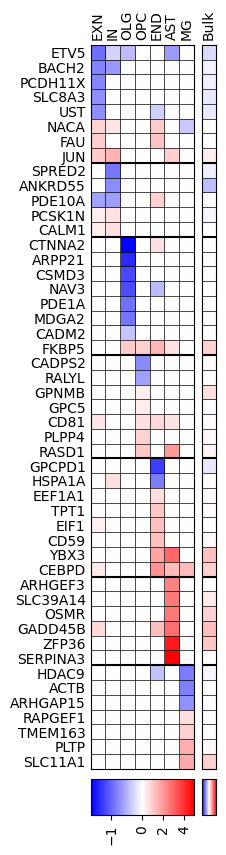

In [31]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
fig, ax = plt.subplots(1,2,figsize=(20,10))
fig.subplots_adjust(wspace=-0.955)
plt.rcParams['font.size']='10'
celltypes = ['EXN','IN','OLG','OPC','END','AST','MG']
norm = mcolors.TwoSlopeNorm(vcenter=0)

p1 = ax[0].imshow(np.array(df2),cmap='bwr',norm=norm)
ax[0].set_xticks(np.arange(len(celltypes)))
ax[0].set_xticklabels(celltypes,rotation=90)
ax[0].set_yticks(np.arange(len(ordered_genes)))
ax[0].set_yticklabels(ordered_genes)

ax[0].set_xticks(np.arange(-0.5,len(celltypes)-1),minor=True)
ax[0].set_xticklabels(celltypes,rotation=90)
ax[0].tick_params(axis=u'both', which=u'both',length=0, top=True, labeltop=True, bottom=False, labelbottom=False)

ax[0].set_xticks(np.arange(-0.5, len(celltypes)-1),minor=True)
ax[0].set_yticks(np.arange(-0.5, df2.shape[0]-1),minor=True)
ax[0].grid(which='minor', color='k', linewidth=0.5)
ax[0].grid(which='major',linewidth=0)

p2 = ax[1].imshow(bulk_vals,cmap='bwr',norm=norm)
ax[1].set_xticks(np.arange(1))
ax[1].set_xticklabels(['Bulk'],rotation=90)
ax[1].set_yticks([])
ax[1].tick_params(axis=u'both', which=u'both',length=0, top=True, labeltop=True, bottom=False, labelbottom=False)

ax[1].set_yticks(np.arange(-0.5, df2.shape[0]-1),minor=True)
ax[1].grid(which='minor', color='k', linewidth=0.5)
ax[1].grid(which='major',linewidth=0)
ax[1].tick_params(axis=u'both', which=u'both',length=0)

from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
divider = make_axes_locatable(ax[0])
cax = divider.append_axes('bottom', size="5%", pad=0.1)
cb = fig.colorbar(p1,ax=ax[0],cax=cax, orientation='horizontal',ticks=[-1,0,2,4])
cb.ax.tick_params(rotation=90)

divider2 = make_axes_locatable(ax[1])
cax2 = divider2.append_axes('bottom', size="5%", pad=0.1)
cb2 = fig.colorbar(p2,ax=ax[1],cax=cax2, orientation='horizontal')
cb2.set_ticks([])

for i in [ax[0],ax[1]]:
    for l in [8,13,21,28,36,42]:
        i.axhline(y=l-0.5,color='k')

# Fig. 1h PTSD snDEGs vs MDD snDEGs Venn

In [32]:
mdd_deg = pd.read_csv('/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/snRNA/MDD_vs_CON/MAST_WILCOX_intersect.csv',sep='\t')
ptsd_deg = pd.read_csv('/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/snRNA/PTSD_vs_CON/MAST_WILCOX_intersect.csv',sep='\t')

In [33]:
mdd_deg = mdd_deg[mdd_deg.Celltype.isin(['EXC','INH','OLI','OPC','END','AST','MIC'])]
ptsd_deg = ptsd_deg[ptsd_deg.Celltype.isin(['EXC','INH','OLI','OPC','END','AST','MIC'])]

In [34]:
ptsd_degs = ptsd_deg.Genename.unique()
mdd_degs = mdd_deg.Genename.unique()

In [35]:
len(ptsd_degs),len(mdd_degs)

(1184, 1918)

In [36]:
inter = list(set(ptsd_degs)&set(mdd_degs))
ptsd_only = list(set(ptsd_degs)-set(inter))

In [37]:
len(inter)

682

In [38]:
len(ptsd_only)

502

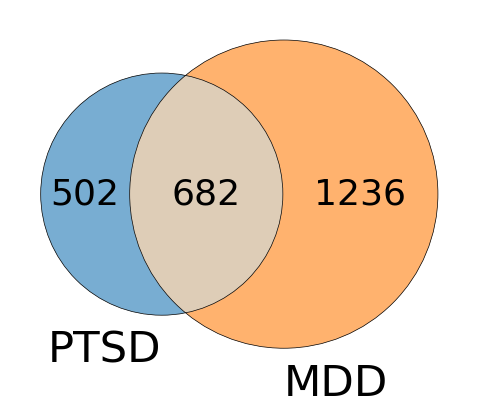

In [41]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = '26'

inter = len(list(set(ptsd_degs) & set(mdd_degs)))
venn2(subsets=(len(ptsd_degs)-inter, len(mdd_degs)-inter, inter), set_labels=('PTSD','MDD'),set_colors=('tab:blue','tab:orange'),alpha=0.6)
venn2_circles(subsets=(len(ptsd_degs)-inter, len(mdd_degs)-inter, inter),linewidth=0.5)

# Fig. 1i 502 PTSD only DEG GO

In [43]:
df = pd.read_csv('/home/ah2428/ShareZhangLab/PTSD/RNA/GO_tables/Supp_Data_Table_20_502_PTSD_specific_GO.txt',sep='\t')

In [44]:
df['-log10FDR'] = -np.log10(df['Adjusted.P.value'])
df = df.sort_values('-log10FDR',ascending=False)

In [45]:
df = df[:13]

Text(0.5, 0, '-log10FDR')

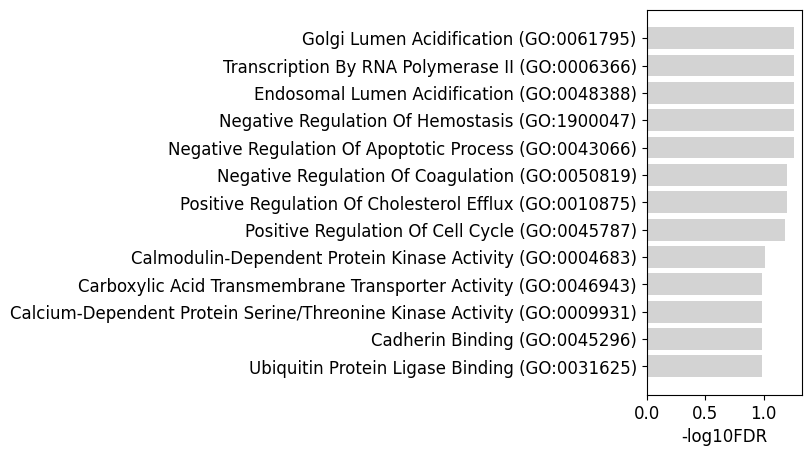

In [46]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size']='12'
fig, ax = plt.subplots(figsize=(2,5))

terms = df.Term.values
terms = terms[::-1]
plt.barh(terms,df['-log10FDR'][::-1],color='lightgray')
plt.xlabel('-log10FDR')

# Fig. 1j PTSD vs MDD Discordant Genes

In [47]:
ptsd_mdd = pg.read_input('/gpfs/gibbs/pi/gerstein/jz435/ShareZhangLab/PTSD/RNA/data/PTSD_MDD.zarr')

2025-04-05 13:50:59,577 - pegasusio.readwrite - INFO - zarr file '/gpfs/gibbs/pi/gerstein/jz435/ShareZhangLab/PTSD/RNA/data/PTSD_MDD.zarr' is loaded.
2025-04-05 13:50:59,578 - pegasusio.readwrite - INFO - Function 'read_input' finished in 180.71s.


In [48]:
ptsd_mdd.obs.subclass = ptsd_mdd.obs.subclass.cat.reorder_categories(['CUX2','RORB','FEZF2','OPRK1','LAMP5','KCNG1','VIP','SST','PVALB','OLI','OPC','END','AST','MIC'])

Text(0.5, 0, ' ')

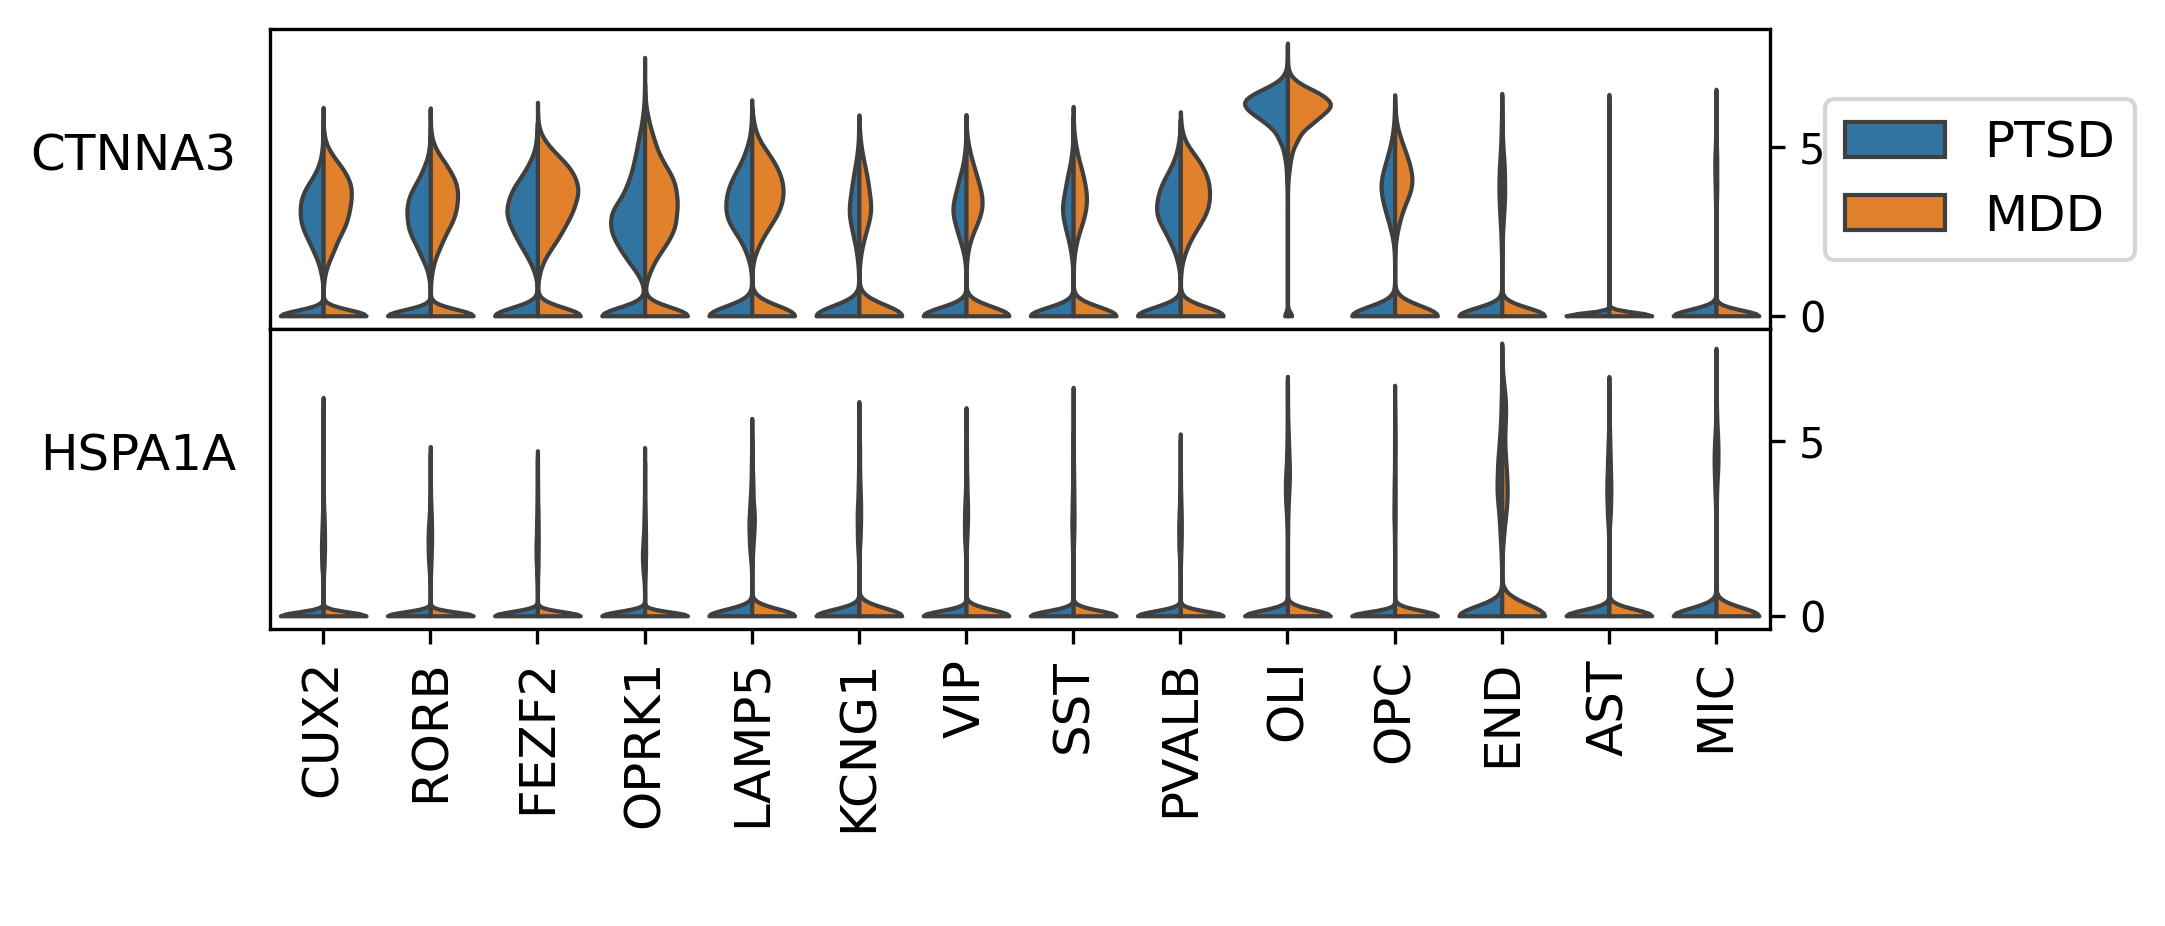

In [49]:
pg.violin(ptsd_mdd,attrs=['CTNNA3','HSPA1A'],groupby='subclass',hue='Condition',panel_size=(5,1))
plt.xlabel(' ')